In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Crops_data.csv")
df.head()

,Dist Code,Year,State Code,State Name,Dist Name,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),...,SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
0,1,2010,14,Chhattisgarh,Durg,777.92,1319.18,1695.77,46.12,45.87,...,256.96,0.00,0.00,0.00,2.00,32.29,34.30,0.11,0.49,0.15
1,1,2011,14,Chhattisgarh,Durg,806.55,1416.48,1756.23,44.98,50.19,...,506.02,0.08,0.02,250.00,0.00,0.00,0.00,0.12,0.54,0.00
2,1,2012,14,Chhattisgarh,Durg,807.07,1534.22,1900.97,43.87,47.69,...,252.98,0.13,0.02,153.85,1.99,33.70,35.69,0.12,0.54,1.32
3,1,2013,14,Chhattisgarh,Durg,819.44,1296.24,1581.86,41.54,43.33,...,237.45,0.05,0.01,200.00,1.90,32.83,34.74,0.11,0.50,0.77
4,1,2014,14,Chhattisgarh,Durg,834.87,1444.24,1729.89,44.25,50.96,...,602.17,0.05,0.02,400.00,0.00,0.00,0.00,0.33,0.51,0.00


In [4]:
df.drop_duplicates(inplace=True)

# this is for handling missing values
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_17531/3638199314.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

y = df['RICE PRODUCTION (1000 tons)']
X = df.drop('RICE PRODUCTION (1000 tons)', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

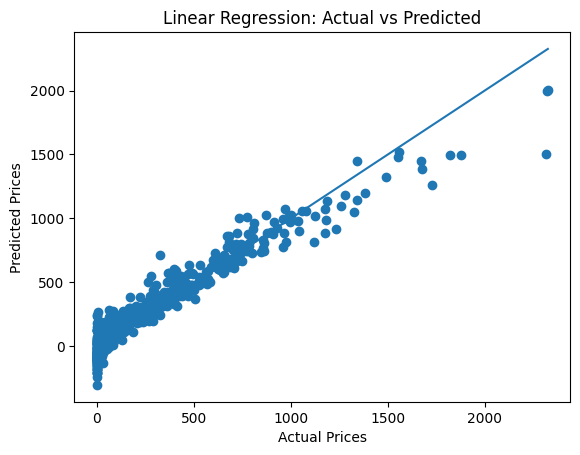

In [8]:
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted")

# Line of perfect prediction
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()